In [50]:
import sys
!{sys.executable} -m pip install shap

import sys
!{sys.executable} -m pip install missingno


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached missingno-0.5.2-py3-none-any.whl.metadata (639 bytes)
Using cached missingno-0.5.2-py3-none-any.whl (8.7 kB)



[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import shap
import warnings
warnings.filterwarnings('ignore')

BG    = '#f9fafb'
GREEN = '#1b5e20'

def green_palette(n):
    return [mcolors.to_hex(c) for c in
            plt.cm.Greens(np.linspace(0.35, 0.9, n))]

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': BG})

C:\Users\ACER\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
df = pd.read_csv('../dataset/Crop_recommendation.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,55,22,43,24.379744,82.002744,6.502985,202.935536,rice
1,50,38,41,25.270462,80.319644,7.038096,226.655537,rice
2,25,35,44,26.504459,82.320763,7.840207,263.964248,rice
3,39,15,40,29.991096,80.158363,6.980401,242.864034,rice
4,43,22,42,23.630175,81.604873,7.628473,262.717340,rice


### Exploratory Data Analysis

In [13]:
display(df.info())
display(df.isnull().sum().to_frame('missing').T)
display(df.describe().round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


None

,N,P,K,temperature,humidity,ph,rainfall,label
missing,0,0,0,0,0,0,0,0


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,48.96,52.45,48.15,25.78,71.48,6.47,103.46
std,36.37,33.41,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,26.00,20.00,23.03,60.26,5.97,64.55
50%,36.00,49.00,32.00,25.82,80.47,6.43,94.87
75%,82.00,68.00,49.00,28.69,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


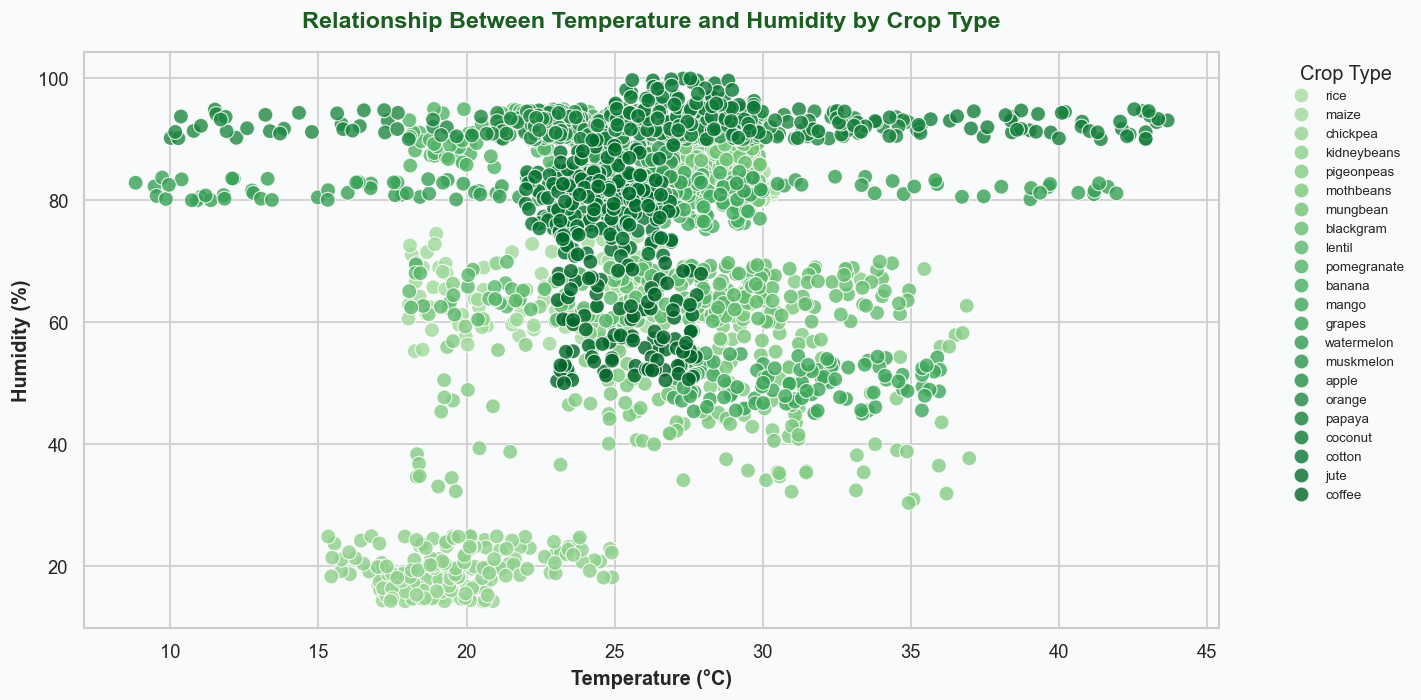

In [ ]:
plt.figure(figsize=(12, 6), facecolor=BG)

sns.scatterplot(
    data=df,
    x='temperature',
    y='humidity',
    hue='label',
    palette=green_palette(df['label'].nunique()), 
    s=80,
    alpha=0.8,
    edgecolor='white'
)

plt.title('Relationship Between Temperature and Humidity by Crop Type', fontsize=14, fontweight='bold', color=GREEN, pad=15)
plt.xlabel('Temperature (°C)', fontweight='bold')
plt.ylabel('Humidity (%)', fontweight='bold')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Crop Type', fontsize='8', frameon=False)
plt.gca().set_facecolor(BG)

plt.tight_layout()
plt.show()

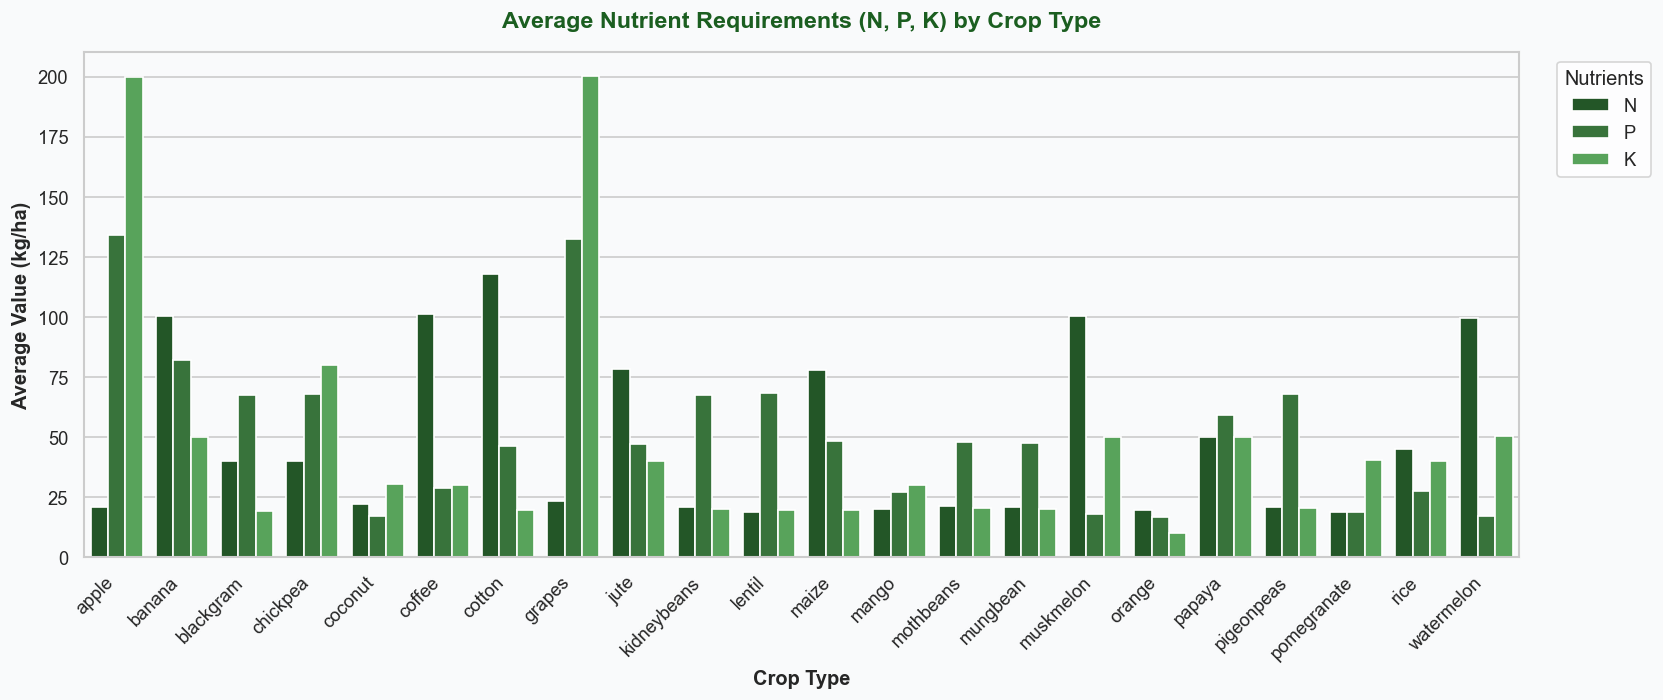

In [ ]:
df_npk = df.groupby('label')[['N', 'P', 'K']].mean().reset_index()
df_npk_melted = df_npk.melt(id_vars='label', var_name='Nutrient', value_name='Average Value')

plt.figure(figsize=(14, 6), facecolor=BG)

sns.barplot(
    data=df_npk_melted,
    x='label',
    y='Average Value',
    hue='Nutrient',
    palette=['#1b5e20', '#2e7d32', '#4caf50'] 
)

plt.title('Average Nutrient Requirements (N, P, K) by Crop Type', fontsize=14, fontweight='bold', color=GREEN, pad=15)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Crop Type', fontweight='bold')
plt.ylabel('Average Value (kg/ha)', fontweight='bold')
plt.gca().set_facecolor(BG)

plt.legend(title='Nutrients', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

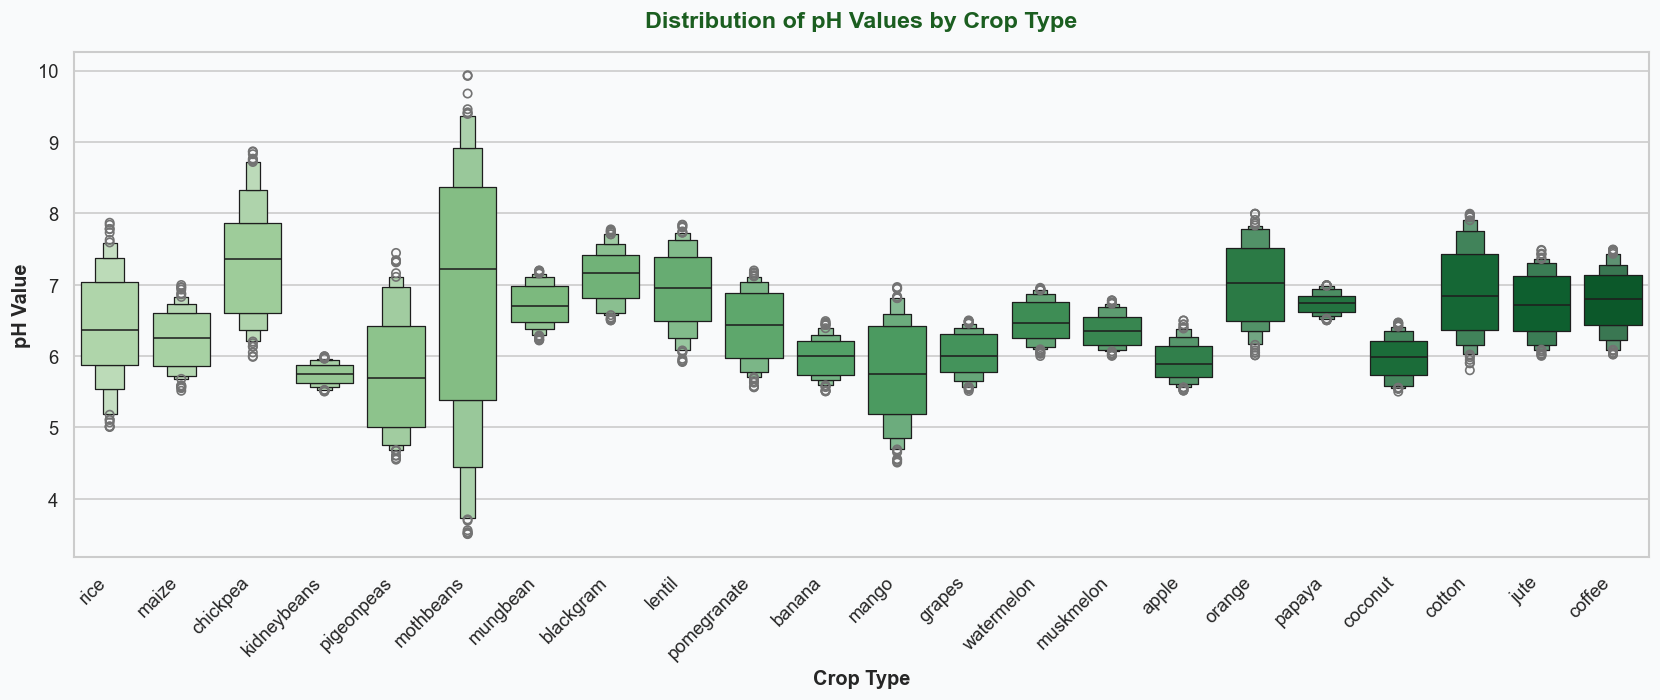

In [38]:
plt.figure(figsize=(14, 6), facecolor=BG)

sns.boxenplot(
    data=df,
    x='label',
    y='ph',
    palette=green_palette(df['label'].nunique())
)

plt.title('Distribution of pH Values by Crop Type', fontsize=14, fontweight='bold', color=GREEN, pad=15)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Crop Type', fontweight='bold')
plt.ylabel('pH Value', fontweight='bold')
plt.gca().set_facecolor(BG)

plt.tight_layout()
plt.show()

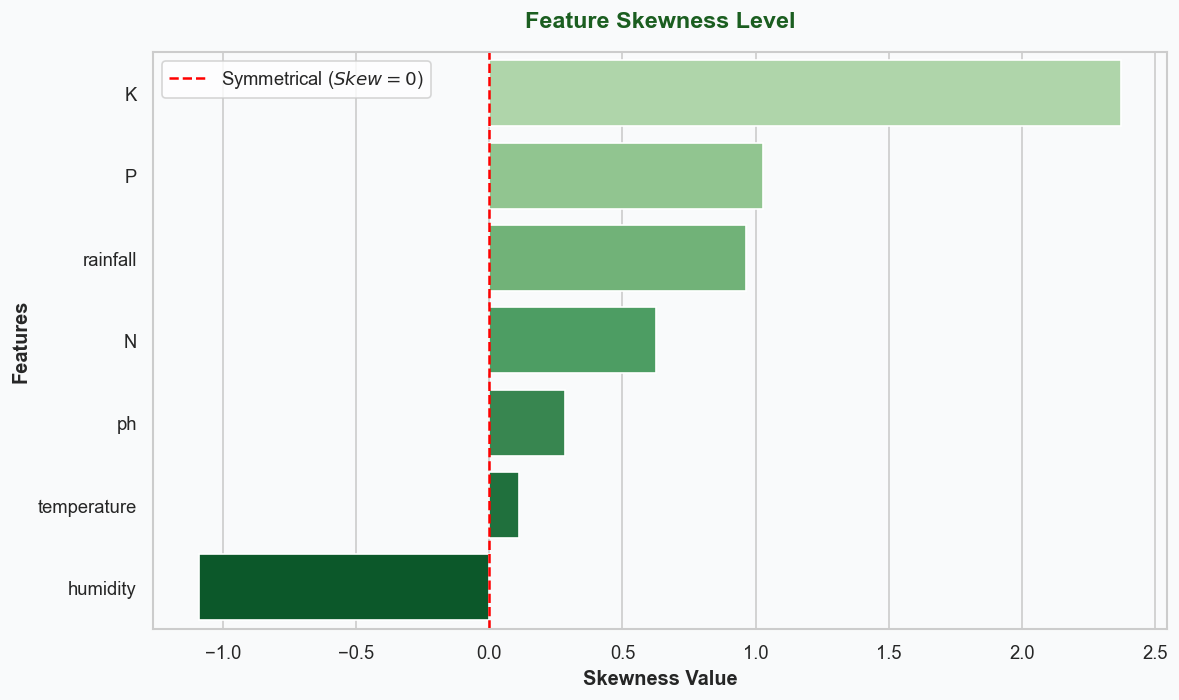

In [ ]:
from scipy.stats import skew

numeric_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
skewness = df[numeric_features].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

plt.figure(figsize=(10, 6), facecolor=BG)

sns.barplot(
    x=skewness.values, 
    y=skewness.index,
    palette=green_palette(len(skewness)),
    orient='h'
)

plt.title('Feature Skewness Level', fontsize=14, fontweight='bold', color=GREEN, pad=15)
plt.xlabel('Skewness Value', fontweight='bold')
plt.ylabel('Features', fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Symmetrical ($Skew = 0$)')
plt.legend()
plt.gca().set_facecolor(BG)

plt.tight_layout()
plt.show()

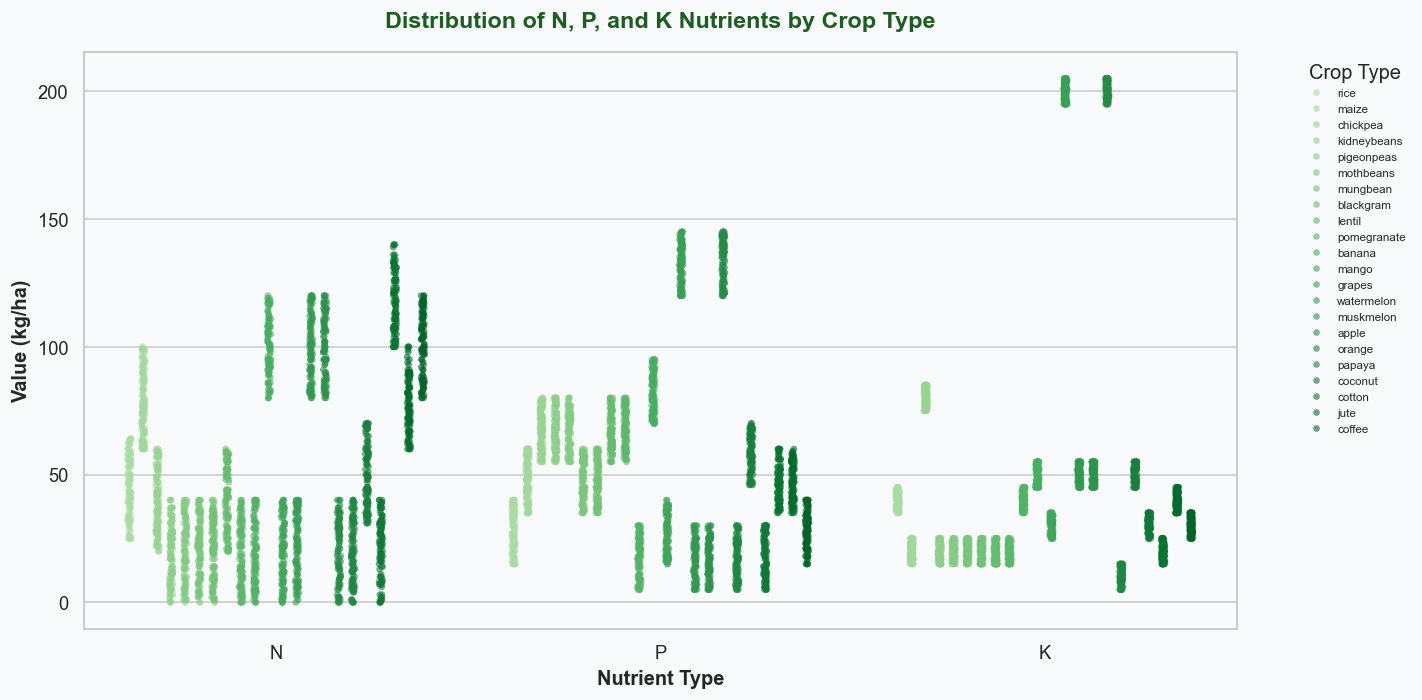

In [42]:
plt.figure(figsize=(12, 6), facecolor=BG)

df_melt = pd.melt(df, id_vars=['label'], value_vars=['N', 'P', 'K'], var_name='Nutrient', value_name='Value')

sns.stripplot(
    data=df_melt,
    x='Nutrient',
    y='Value',
    hue='label',
    palette=green_palette(df['label'].nunique()),
    dodge=True,
    alpha=0.6,
    size=4
)

plt.title('Distribution of N, P, and K Nutrients by Crop Type', fontsize=14, fontweight='bold', color=GREEN, pad=15)
plt.xlabel('Nutrient Type', fontweight='bold')
plt.ylabel('Value (kg/ha)', fontweight='bold')
plt.gca().set_facecolor(BG)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Crop Type', fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

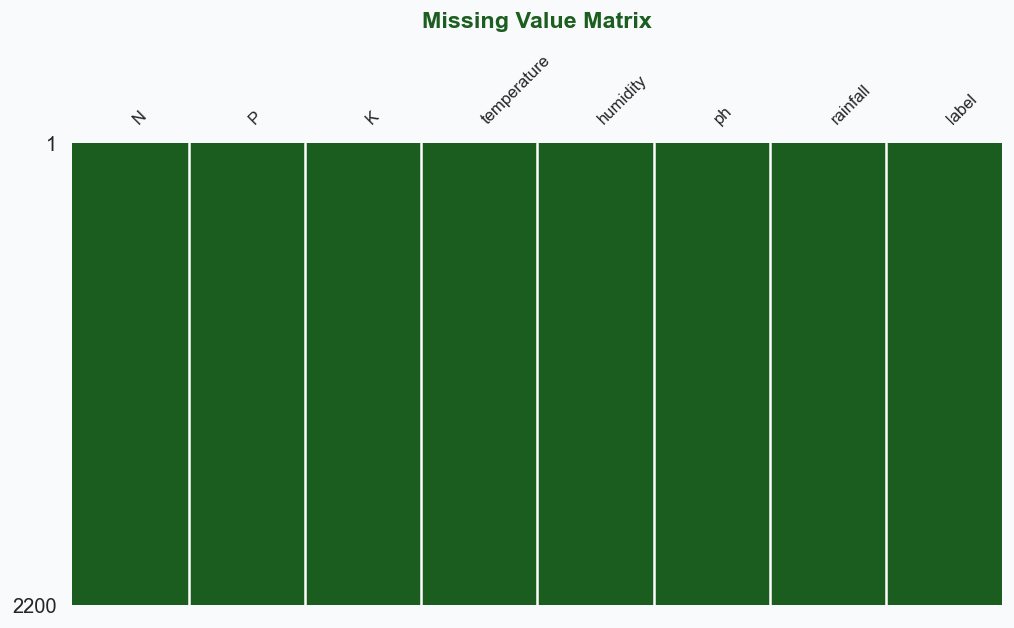

In [51]:
import missingno as msno

# Membuat plot untuk melihat missing values
fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
msno.matrix(df, ax=ax, color=(0.105, 0.368, 0.125), fontsize=10)
ax.set_title('Missing Value Matrix', fontsize=14, fontweight='bold', color=GREEN, pad=15)
ax.set_facecolor(BG)
plt.show()

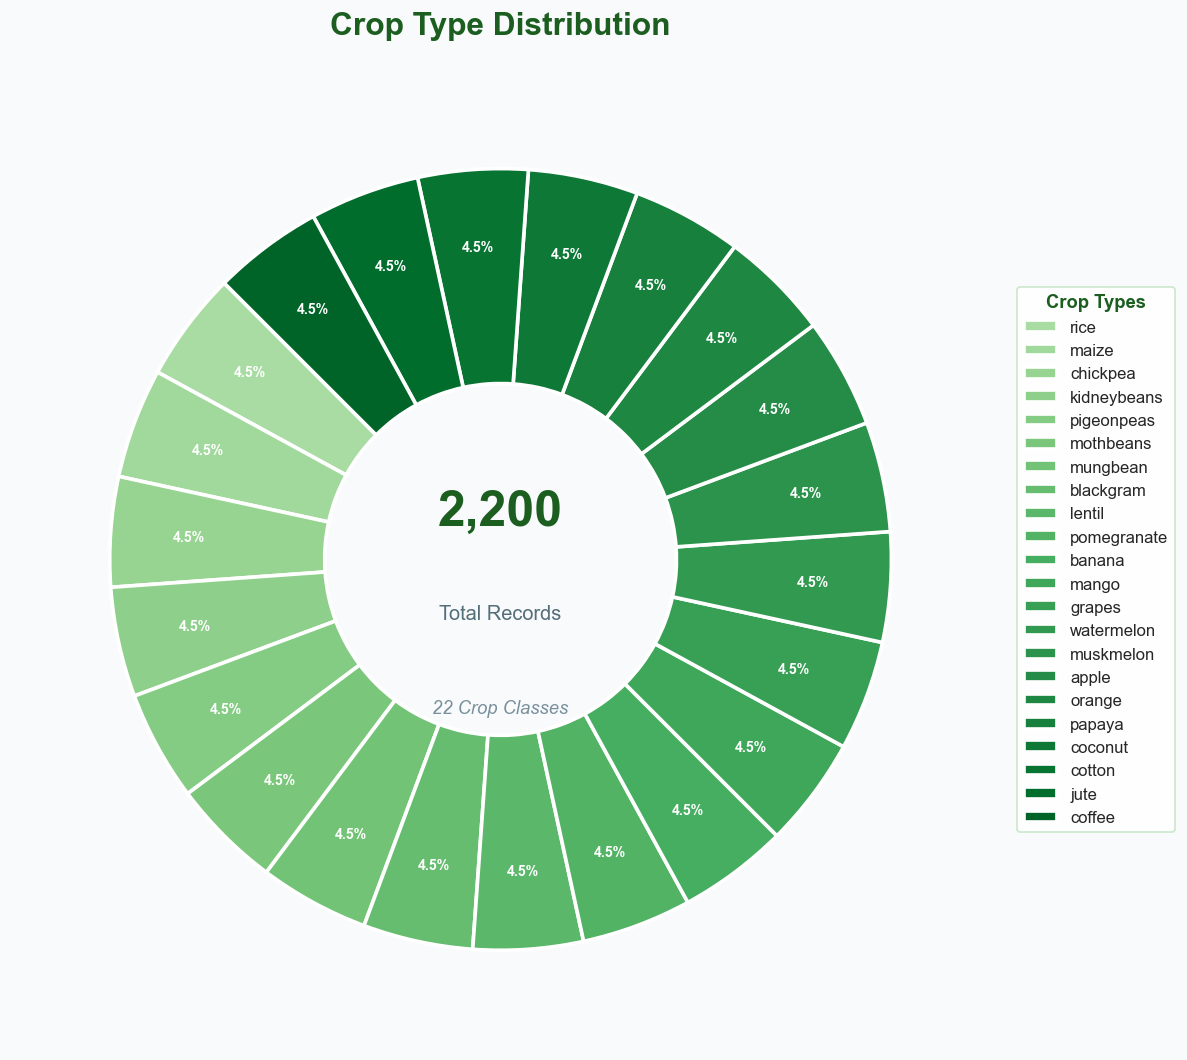

In [14]:
counts  = df['label'].value_counts().sort_values(ascending=False)
n_crops = len(counts)
colors  = green_palette(n_crops)

fig, ax = plt.subplots(figsize=(14, 9), facecolor=BG)
ax.set_facecolor(BG)

wedges, texts, autotexts = ax.pie(
    counts, labels=None, colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 4.0 else '',
    startangle=135, pctdistance=0.80,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.2),
    textprops=dict(size=9),
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(8.5)

ax.text(0,  0.12, '2,200',         ha='center', va='center', fontsize=30, fontweight='bold', color=GREEN)
ax.text(0, -0.14, 'Total Records', ha='center', va='center', fontsize=12, color='#546e7a')
ax.text(0, -0.38, f'{n_crops} Crop Classes', ha='center', va='center', fontsize=11, color='#78909c', style='italic')

legend = ax.legend(
    wedges, counts.index,
    title='Crop Types', title_fontsize=11,
    loc='center left', bbox_to_anchor=(1.02, 0.5),
    fontsize=10, frameon=True, framealpha=0.95,
    edgecolor='#c8e6c9', ncol=1,
)
legend.get_title().set_color(GREEN)
legend.get_title().set_fontweight('bold')

ax.set_title('Crop Type Distribution', fontsize=19, fontweight='bold', pad=22, color=GREEN)
plt.tight_layout()
plt.show()

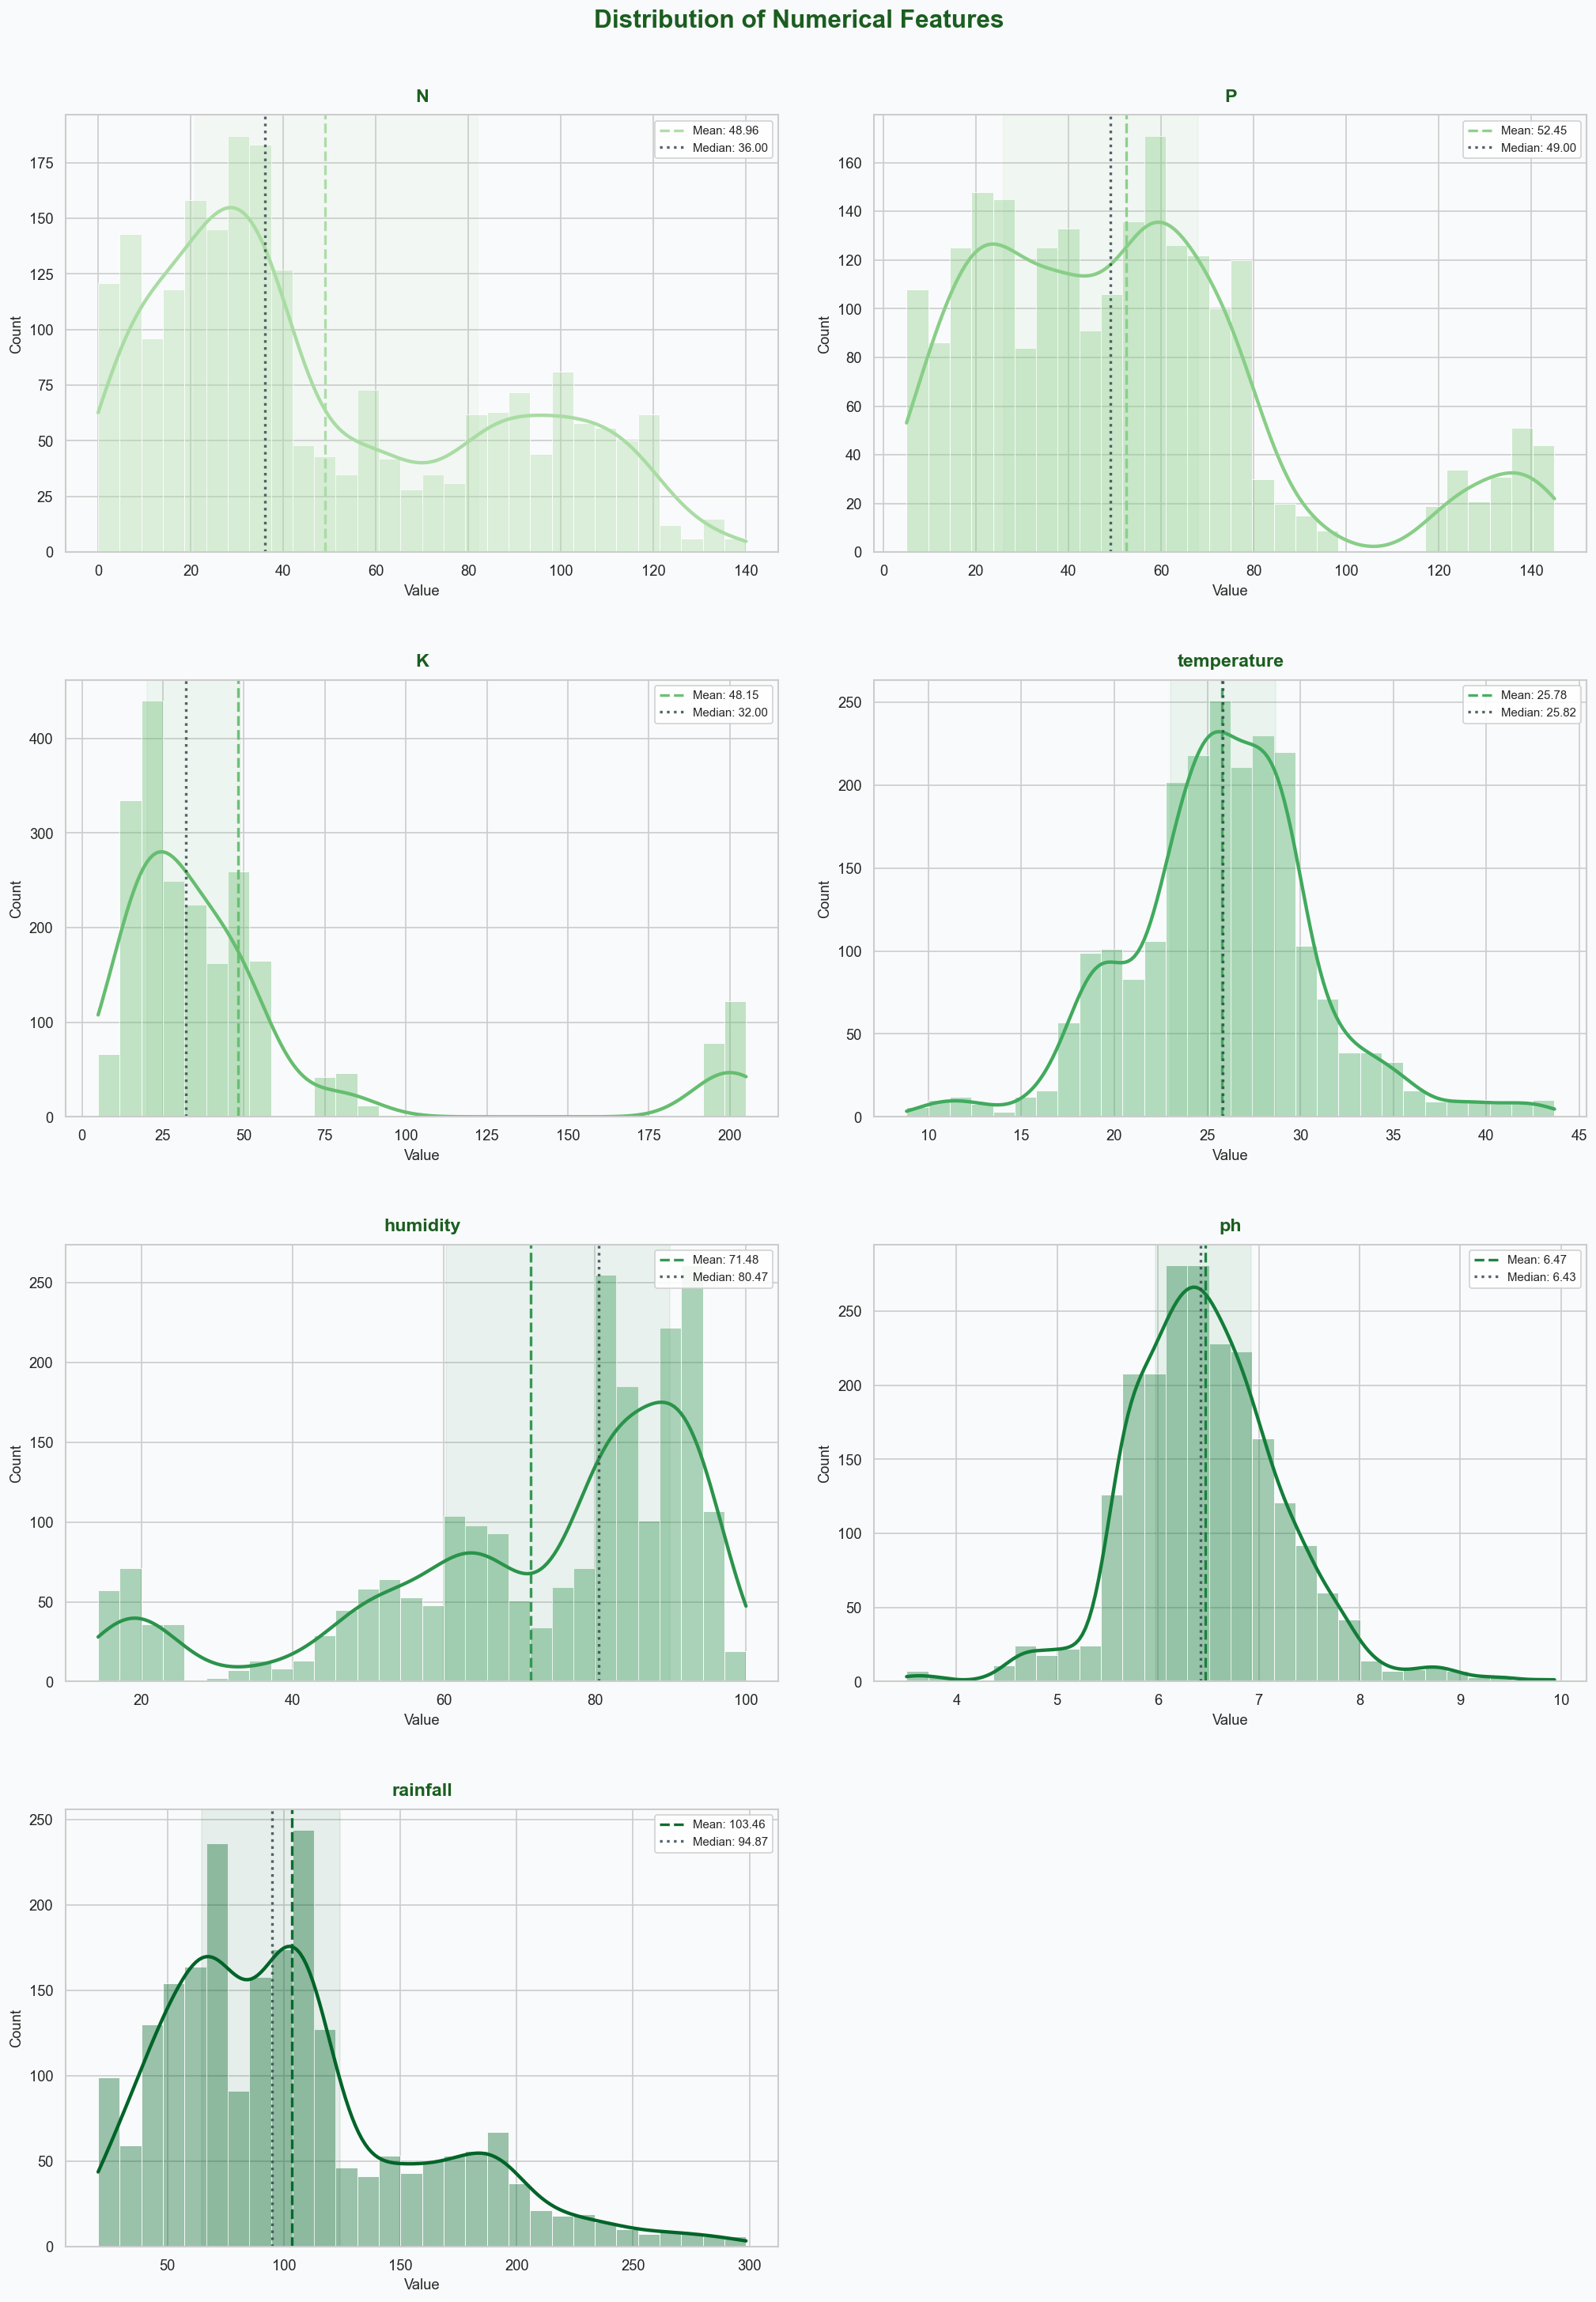

In [15]:
num_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
colors = green_palette(7)

fig, axes = plt.subplots(4, 2, figsize=(17, 24), facecolor=BG)
axes = axes.flatten()

for i, (col, color) in enumerate(zip(num_features, colors)):
    ax = axes[i]
    ax.set_facecolor(BG)
    data = df[col]
    sns.histplot(data, kde=True, ax=ax, color=color, bins=30,
                 alpha=0.38, edgecolor='white', linewidth=0.5)
    for line in ax.get_lines():
        line.set_linewidth(2.6)
        line.set_color(color)
    mean_val, median_val = data.mean(), data.median()
    ax.axvline(mean_val,   color=color,     lw=2.0, ls='--', alpha=0.95, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='#37474f', lw=2.0, ls=':',  alpha=0.85, label=f'Median: {median_val:.2f}')
    ax.axvspan(df[col].quantile(0.25), df[col].quantile(0.75), alpha=0.08, color=color)
    ax.set_title(col, fontsize=14, fontweight='bold', color=GREEN, pad=10)
    ax.set_xlabel('Value', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=9, loc='upper right', framealpha=0.88)

axes[-1].set_visible(False)
fig.suptitle('Distribution of Numerical Features', fontsize=19, fontweight='bold', color=GREEN, y=1.01)
plt.tight_layout(h_pad=3.5, w_pad=2.5)
plt.show()

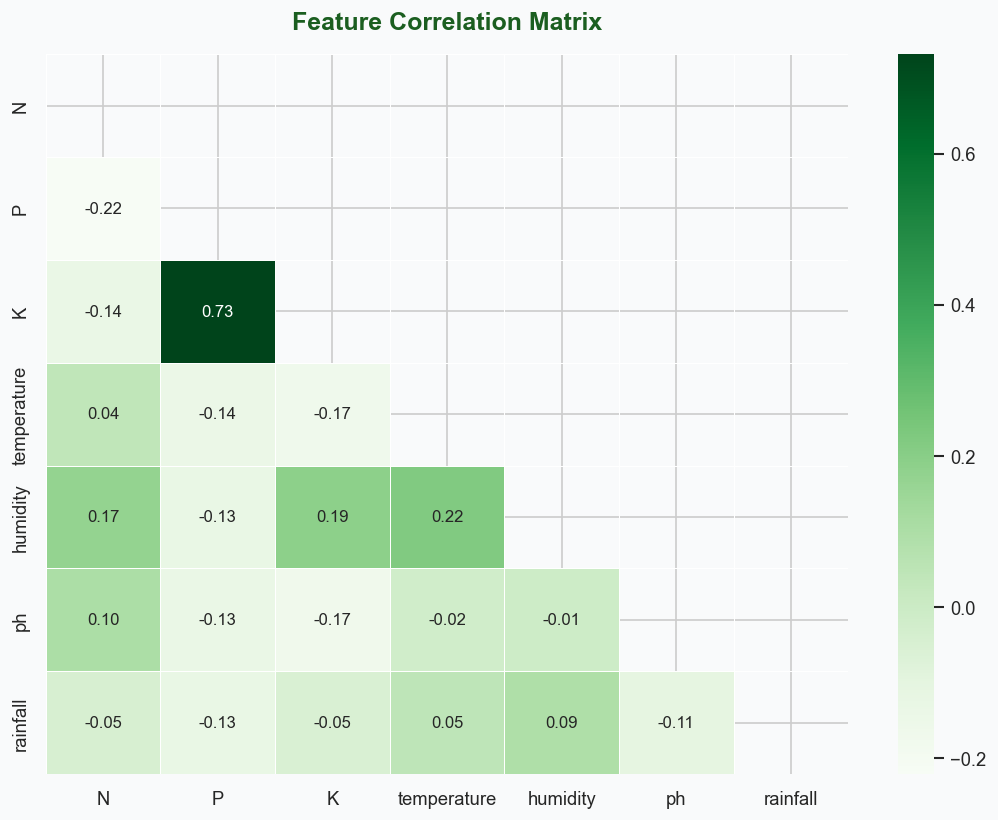

In [16]:
corr = df.drop('label', axis=1).corr()

fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
ax.set_facecolor(BG)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='Greens',
            mask=np.triu(np.ones_like(corr, dtype=bool)),
            linewidths=0.5, ax=ax, annot_kws={'size': 10})

ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold', color=GREEN, pad=15)
plt.tight_layout()
plt.show()

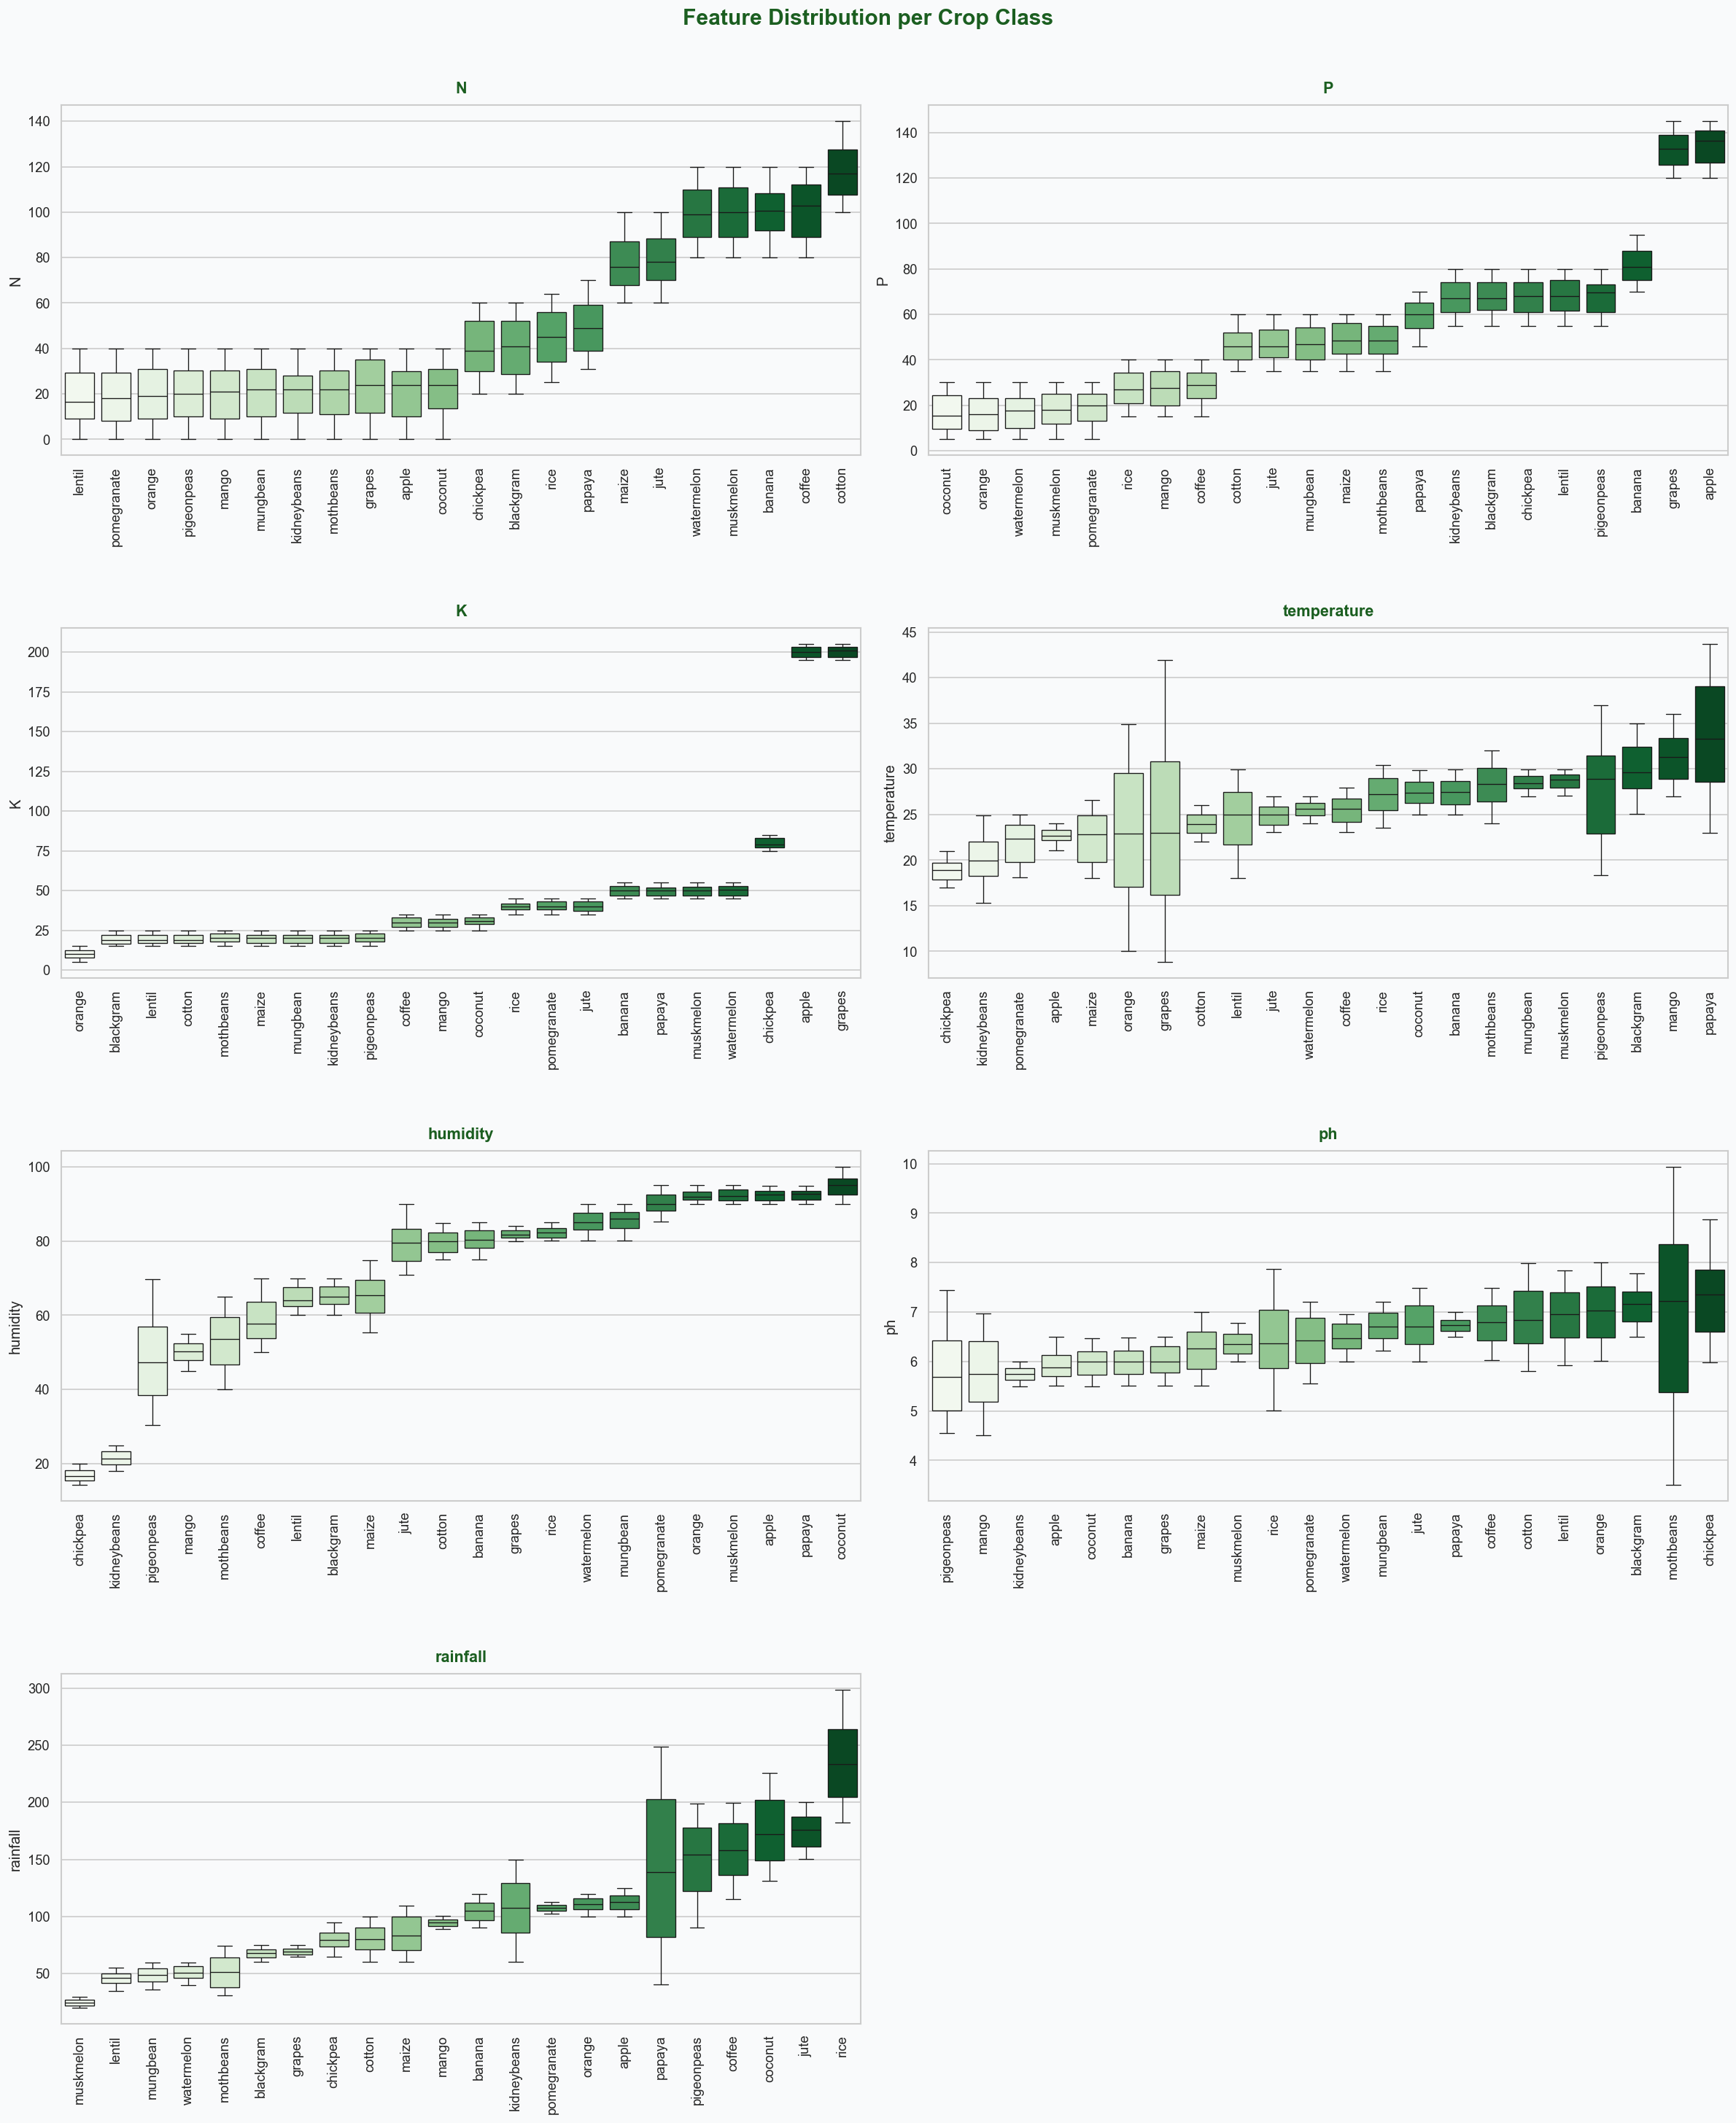

In [17]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(4, 2, figsize=(20, 24), facecolor=BG)
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    ax.set_facecolor(BG)
    order = df.groupby('label')[col].median().sort_values().index
    sns.boxplot(data=df, x='label', y=col, order=order, ax=ax,
                palette='Greens', linewidth=0.8, fliersize=2)
    ax.set_title(col, fontsize=13, fontweight='bold', color=GREEN, pad=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=90)

axes[-1].set_visible(False)
fig.suptitle('Feature Distribution per Crop Class', fontsize=18, fontweight='bold', color=GREEN, y=1.01)
plt.tight_layout(h_pad=4)
plt.show()

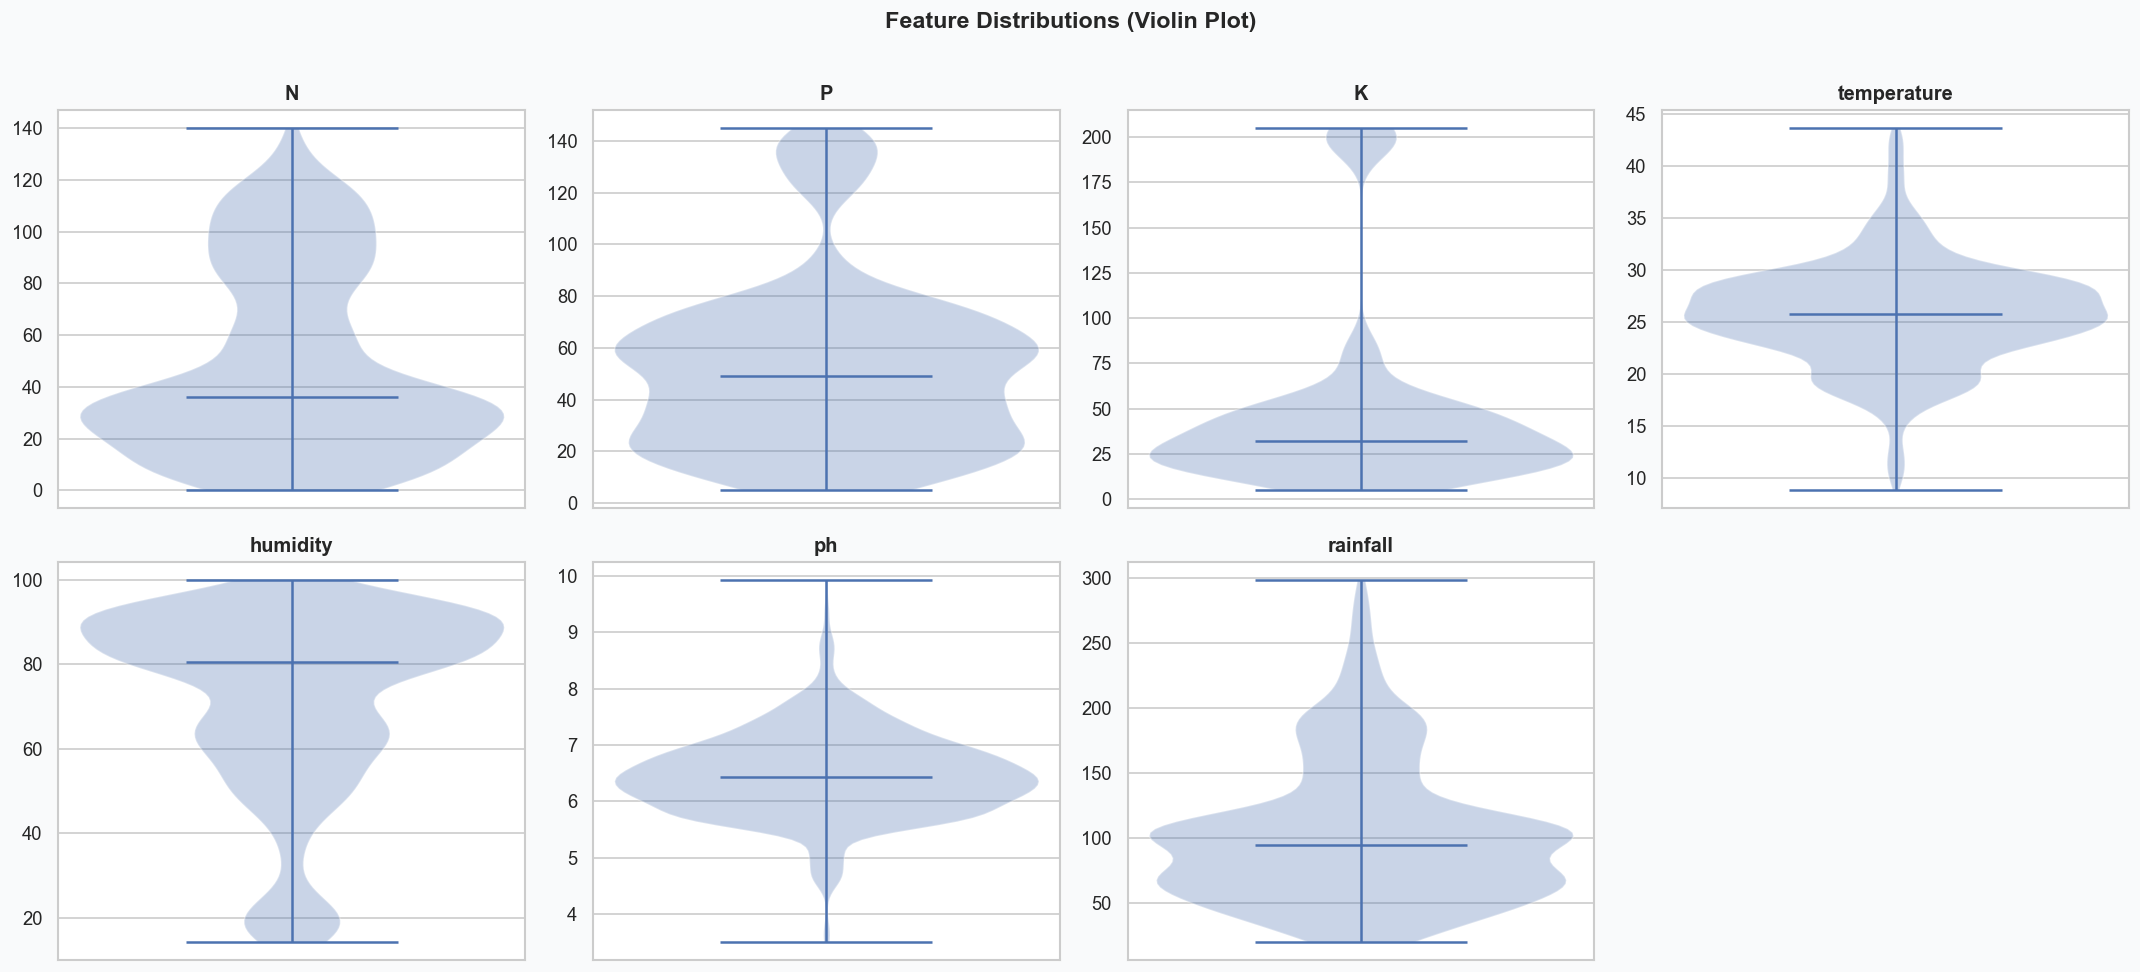

Outlier count per feature (IQR method):
  N           : 0 outliers (0.0%)
  P           : 122 outliers (5.5%)
  K           : 200 outliers (9.1%)
  temperature : 87 outliers (4.0%)
  humidity    : 30 outliers (1.4%)
  ph          : 57 outliers (2.6%)
  rainfall    : 100 outliers (4.5%)


In [18]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].violinplot(df[col], vert=True, showmedians=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticks([])

axes[-1].axis('off')
plt.suptitle('Feature Distributions (Violin Plot)', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Outlier count per feature (IQR method):')
for col in features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'  {col:<12}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

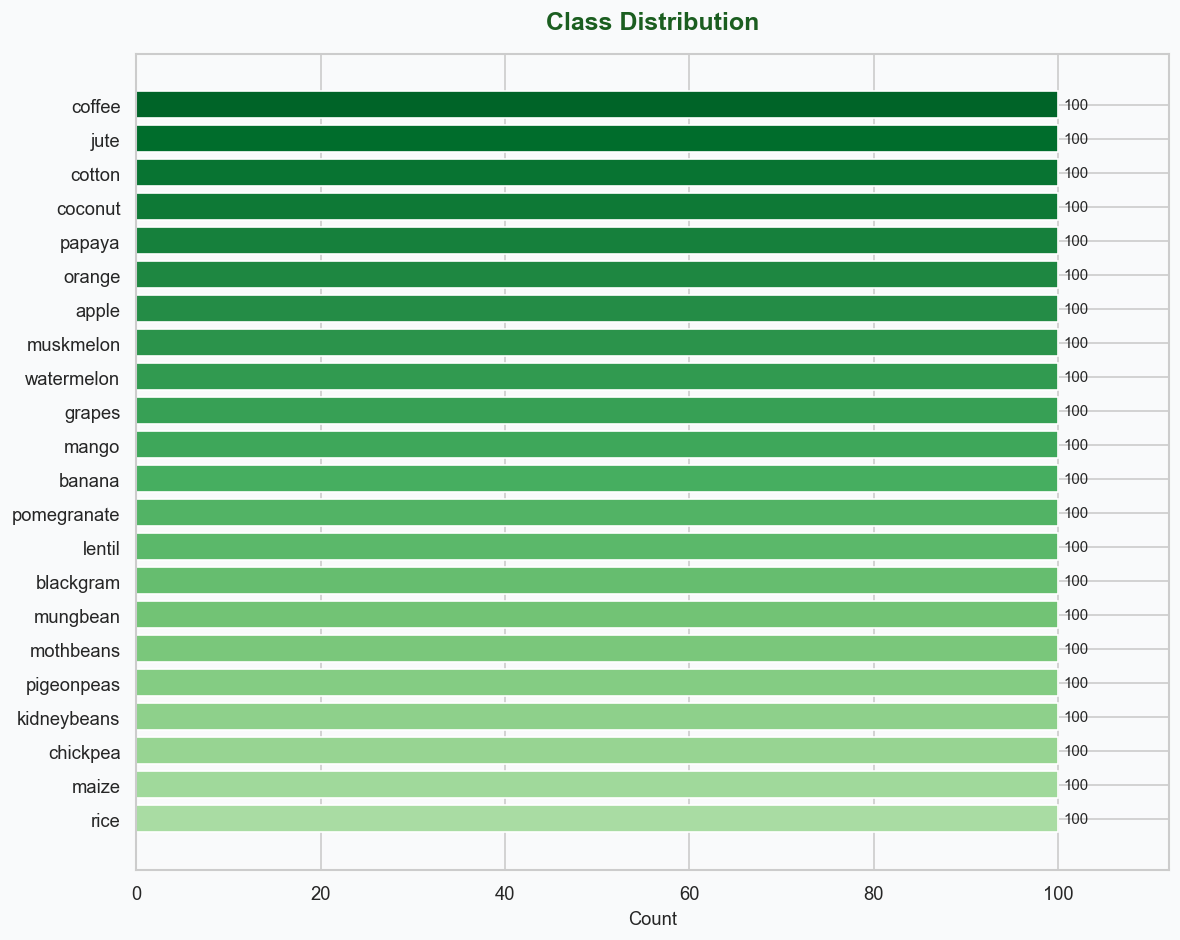

In [19]:
label_counts = df['label'].value_counts()
colors = green_palette(len(label_counts))

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.barh(label_counts.index, label_counts.values, color=colors)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Class Distribution', fontsize=15, fontweight='bold', color=GREEN, pad=15)
ax.set_xlabel('Count', fontsize=11)
ax.set_xlim(0, label_counts.max() * 1.12)
plt.tight_layout()
plt.show()

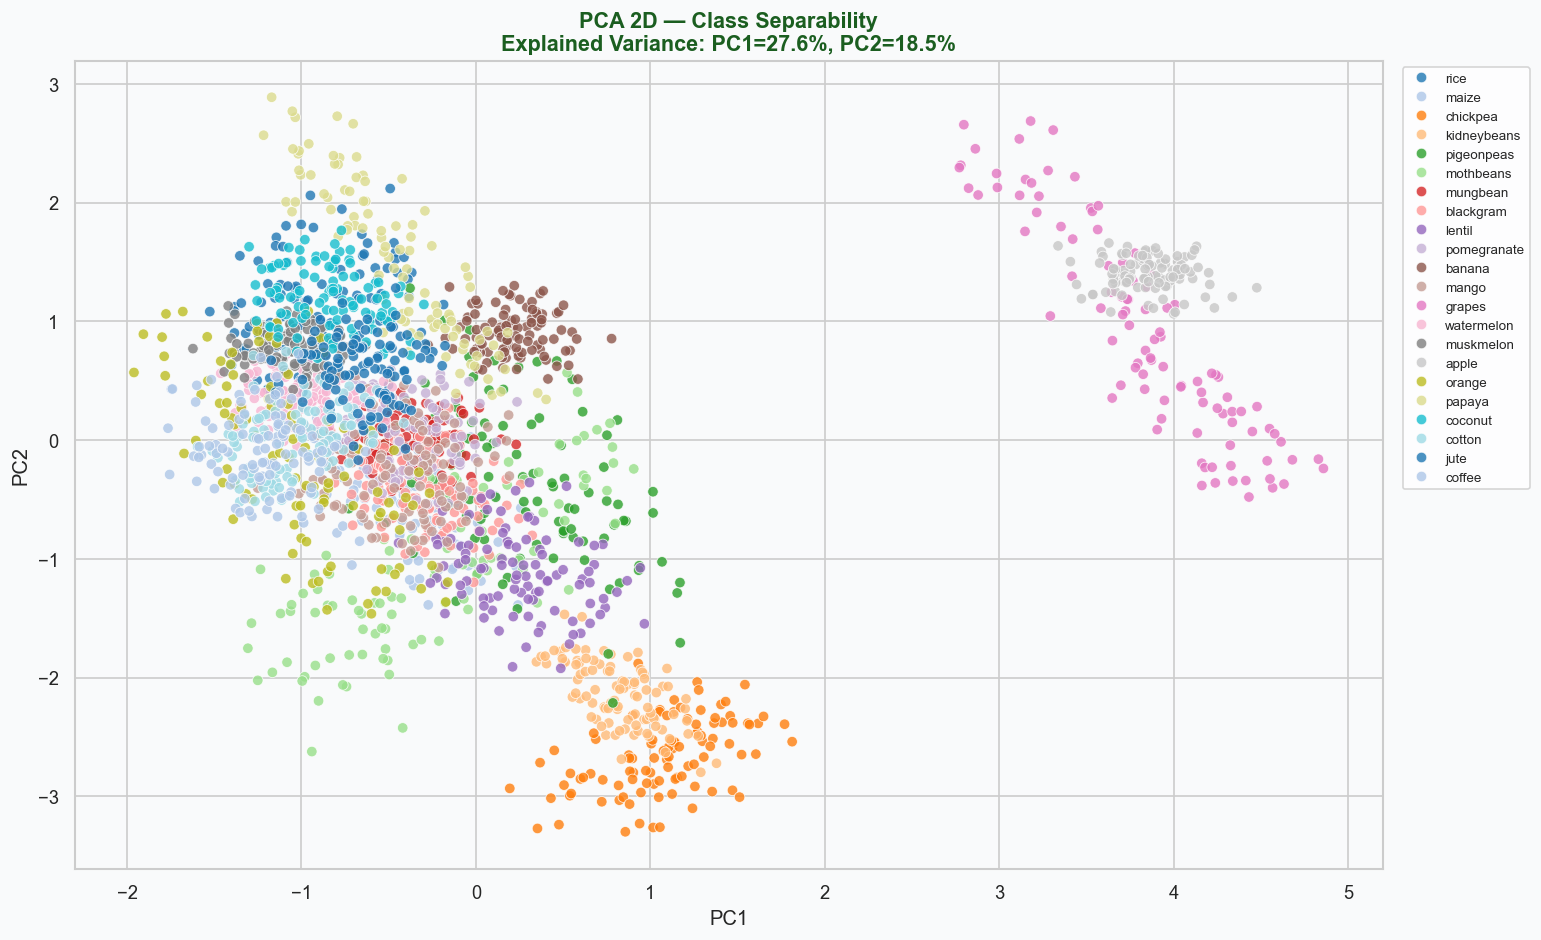

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_pca = StandardScaler().fit_transform(df.drop('label', axis=1))
pca   = PCA(n_components=2)
comps = pca.fit_transform(X_pca)

pca_df = pd.DataFrame(comps, columns=['PC1', 'PC2'])
pca_df['label'] = df['label'].values

fig, ax = plt.subplots(figsize=(13, 8), facecolor=BG)
ax.set_facecolor(BG)

palette = sns.color_palette('tab20', n_colors=pca_df['label'].nunique())
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='label',
                palette=palette, s=40, alpha=0.8, ax=ax)

ax.set_title(
    f'PCA 2D — Class Separability\n'
    f'Explained Variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}',
    fontsize=13, fontweight='bold', color=GREEN
)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Preprocessing

In [21]:
X = df.drop('label', axis=1)
y = df['label']

# Log transformation pada rainfall
# CHIRPS Indonesia menghasilkan ~400mm/bulan, melebihi batas atas dataset (298mm)
# log1p meredam nilai ekstrem agar tetap dalam distribusi yang dapat dipelajari model
X['rainfall'] = np.log1p(X['rainfall'])

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Rainfall setelah log1p — Min: {X.rainfall.min():.4f} | Max: {X.rainfall.max():.4f}')
unique, counts = np.unique(y_train, return_counts=True)
print(f'Class balance — Min: {counts.min()} | Max: {counts.max()} | Mean: {counts.mean():.1f}')

Train: (1760, 7) | Test: (440, 7)
Rainfall setelah log1p — Min: 3.0545 | Max: 5.7023
Class balance — Min: 80 | Max: 80 | Mean: 80.0


In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Decision Tree (Baseline)': DecisionTreeClassifier(random_state=42),
    'Random Forest'           : RandomForestClassifier(
                                    n_estimators=100,
                                    max_depth=15,
                                    min_samples_leaf=10,
                                    min_samples_split=20,
                                    max_features='sqrt',
                                    random_state=42
                                )
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('scaler', MinMaxScaler()), ('clf', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=['accuracy', 'f1_weighted'],
                            return_train_score=True)
    results[name] = {
        'Train Acc'   : scores['train_accuracy'].mean(),
        'Val Acc'     : scores['test_accuracy'].mean(),
        'Val Acc Std' : scores['test_accuracy'].std(),
        'Val F1'      : scores['test_f1_weighted'].mean(),
    }

display(pd.DataFrame(results).T.round(4))

,Train Acc,Val Acc,Val Acc Std,Val F1
Decision Tree (Baseline),1.0000,0.9847,0.0064,0.9846
Random Forest,0.9993,0.9960,0.0029,0.9960


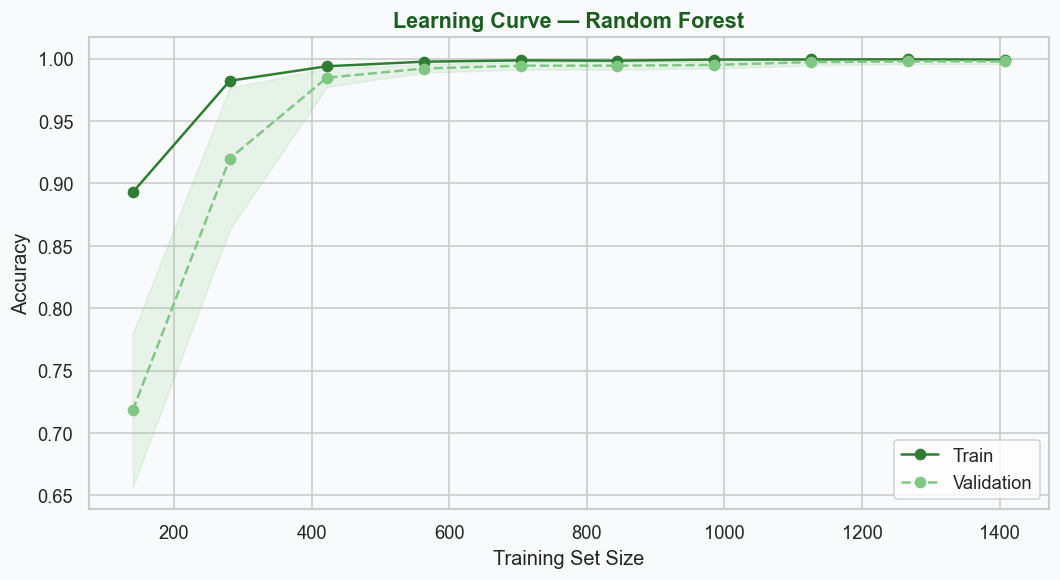

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       1.00      1.00      1.00        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

In [23]:
final_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=10,
        min_samples_split=20,
        max_features='sqrt',
        random_state=42
    ))
])

train_sizes, train_scores, val_scores = learning_curve(
    final_pipe, X_train, y_train,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.figure(figsize=(9, 5), facecolor=BG)
plt.gca().set_facecolor(BG)
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-',  color='#2e7d32', label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1),   'o--', color='#81c784', label='Validation')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.15, color='#81c784')
plt.title('Learning Curve — Random Forest', fontweight='bold', fontsize=13, color=GREEN)
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

final_pipe.fit(X_train, y_train)
y_pred = final_pipe.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

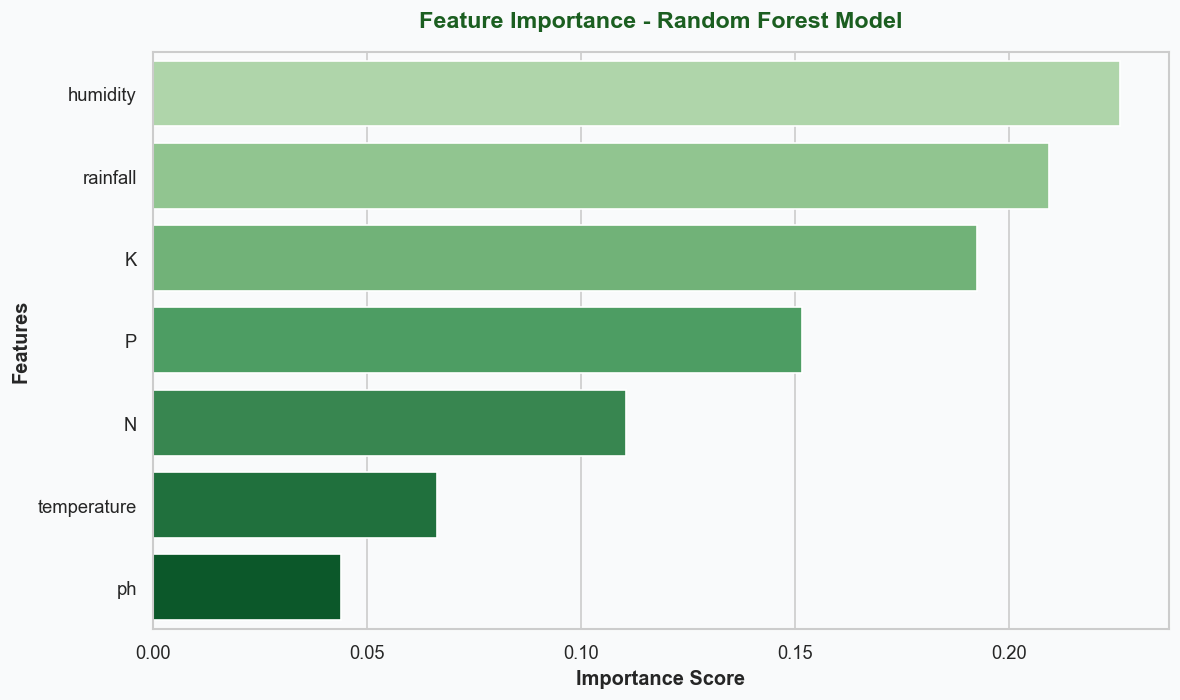

In [53]:
rf_model = final_pipe.named_steps['clf']

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6), facecolor=BG)
sns.barplot(
    data=importances, 
    x='Importance', 
    y='Feature', 
    palette=green_palette(len(importances))
)

plt.title('Feature Importance - Random Forest Model', fontsize=14, fontweight='bold', color=GREEN, pad=15)
plt.xlabel('Importance Score', fontweight='bold')
plt.ylabel('Features', fontweight='bold')

plt.gca().set_facecolor(BG)
plt.tight_layout()

plt.show()

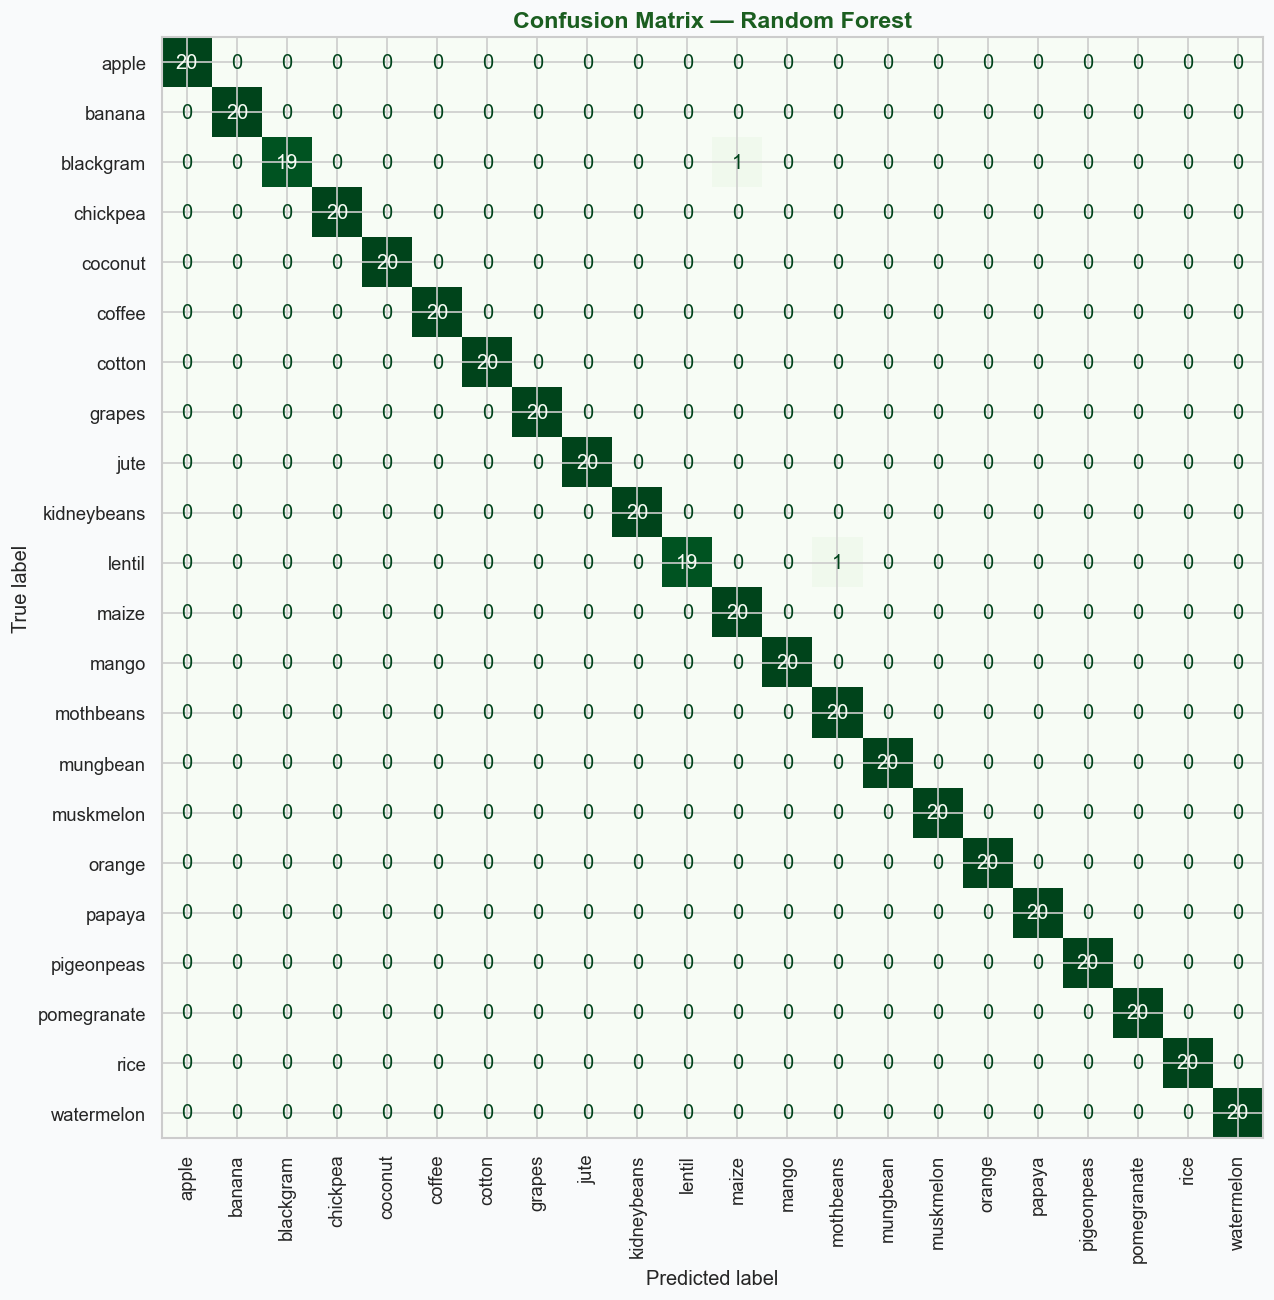

In [24]:
fig, ax = plt.subplots(figsize=(13, 11), facecolor=BG)
ax.set_facecolor(BG)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    cmap='Greens', ax=ax, colorbar=False,
    xticks_rotation=90
)

ax.set_title('Confusion Matrix — Random Forest', fontweight='bold', fontsize=14, color=GREEN)
plt.tight_layout()
plt.show()

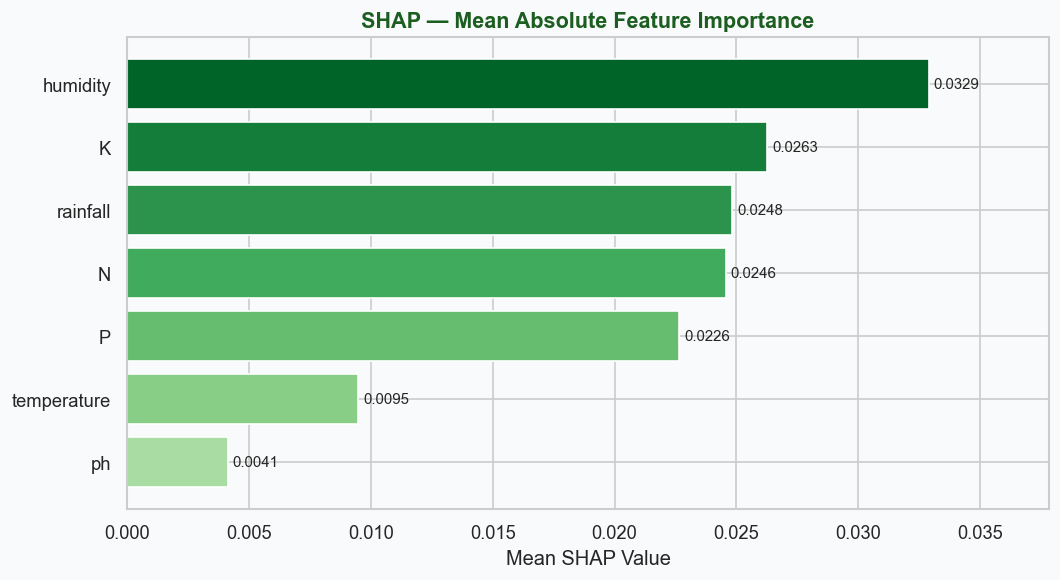

In [25]:
rf_model = final_pipe.named_steps['clf']
scaler   = final_pipe.named_steps['scaler']
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

shap_array = np.array(shap_values)
mean_shap  = np.abs(shap_array).mean(axis=(0, 2)) if shap_array.ndim == 3 else np.abs(shap_array).mean(axis=0)

shap_df = pd.DataFrame({'Feature': X.columns, 'SHAP': mean_shap}).sort_values('SHAP', ascending=True)
colors  = green_palette(len(shap_df))

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.barh(shap_df['Feature'], shap_df['SHAP'], color=colors)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_title('SHAP — Mean Absolute Feature Importance', fontweight='bold', fontsize=13, color=GREEN)
ax.set_xlabel('Mean SHAP Value')
ax.set_xlim(0, shap_df['SHAP'].max() * 1.15)
plt.tight_layout()
plt.show()

In [26]:
import joblib
import json

joblib.dump(final_pipe.named_steps['scaler'], 'minmax_scaler.pkl')
joblib.dump(final_pipe.named_steps['clf'],    'random_forest_model.pkl')
joblib.dump(le,                               'label_encoder.pkl')
json.dump({'rainfall_transform': 'log1p'}, open('model_config.json', 'w'))

print('Saved: minmax_scaler.pkl')
print('Saved: random_forest_model.pkl')
print('Saved: label_encoder.pkl')
print('Saved: model_config.json — rainfall_transform: log1p')

loaded_scaler = joblib.load('minmax_scaler.pkl')
loaded_model  = joblib.load('random_forest_model.pkl')
loaded_le     = joblib.load('label_encoder.pkl')

sample = loaded_scaler.transform(X_test.iloc[[0]])
pred   = loaded_le.inverse_transform(loaded_model.predict(sample))[0]
actual = loaded_le.inverse_transform([y_test[0]])[0]

print(f'\nSanity check — Predicted: {pred} | Actual: {actual}')

Saved: minmax_scaler.pkl
Saved: random_forest_model.pkl
Saved: label_encoder.pkl
Saved: model_config.json — rainfall_transform: log1p

Sanity check — Predicted: orange | Actual: orange
